# Wilson-Cowan Pairwise Model

---
## **1. Theoretical Introduction**

### **1.1. Wilson-Cowan Model**
The Wilson-Cowan model describes the dynamics of excitatory (E) and inhibitory (I) neural populations with pairwise interactions.

#### **Model Equations:**
- **Excitatory Population:**
  $$
  \tau_E \frac{dE_i}{dt} = -E_i + S\left(c_{EE} E_i - c_{IE} I_i + P + K \sum_{j} M_{ij} E_j\right)
  $$

- **Inhibitory Population:**
  $$
  \tau_I \frac{dI_i}{dt} = -I_i + S\left(c_{EI} E_i - c_{II} I_i + Q\right)
  $$

#### **Sigmoid Function:**
$$
S(v) = \frac{1}{1 + e^{-a v}}
$$

---
## **2. Initial Setup**
We import the functions already defined in the `Scripts` folder.


In [1]:
import sys
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder

from Scripts_BackUps.parameters import *
from Scripts_BackUps.dynamics import *
from Scripts_BackUps.simulation import *
from Scripts_BackUps.oscillation_detection import *
from Scripts_BackUps.metrics import *
from Scripts_BackUps.visualization import *

print("Functions loaded successfully.")

Stable Rank: 1.50
Nuclear Rank: 2.00
Effective Rank (Energy Ratio 95%): 3
Functions loaded successfully.


---
## **3. Basic Simulation and Signal Plotting**
We simulate the model with default parameters and visualize the signals.


Total timesteps: 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.4947, std=0.1677, range=[0.2571, 0.7370]
  I: mean=0.4682, std=0.0854, range=[0.3424, 0.6014]

Node 1:
  E: mean=0.4954, std=0.1689, range=[0.2508, 0.7597]
  I: mean=0.4684, std=0.0855, range=[0.3414, 0.6029]

Node 2:
  E: mean=0.4953, std=0.1688, range=[0.2515, 0.7572]
  I: mean=0.4684, std=0.0855, range=[0.3414, 0.6029]


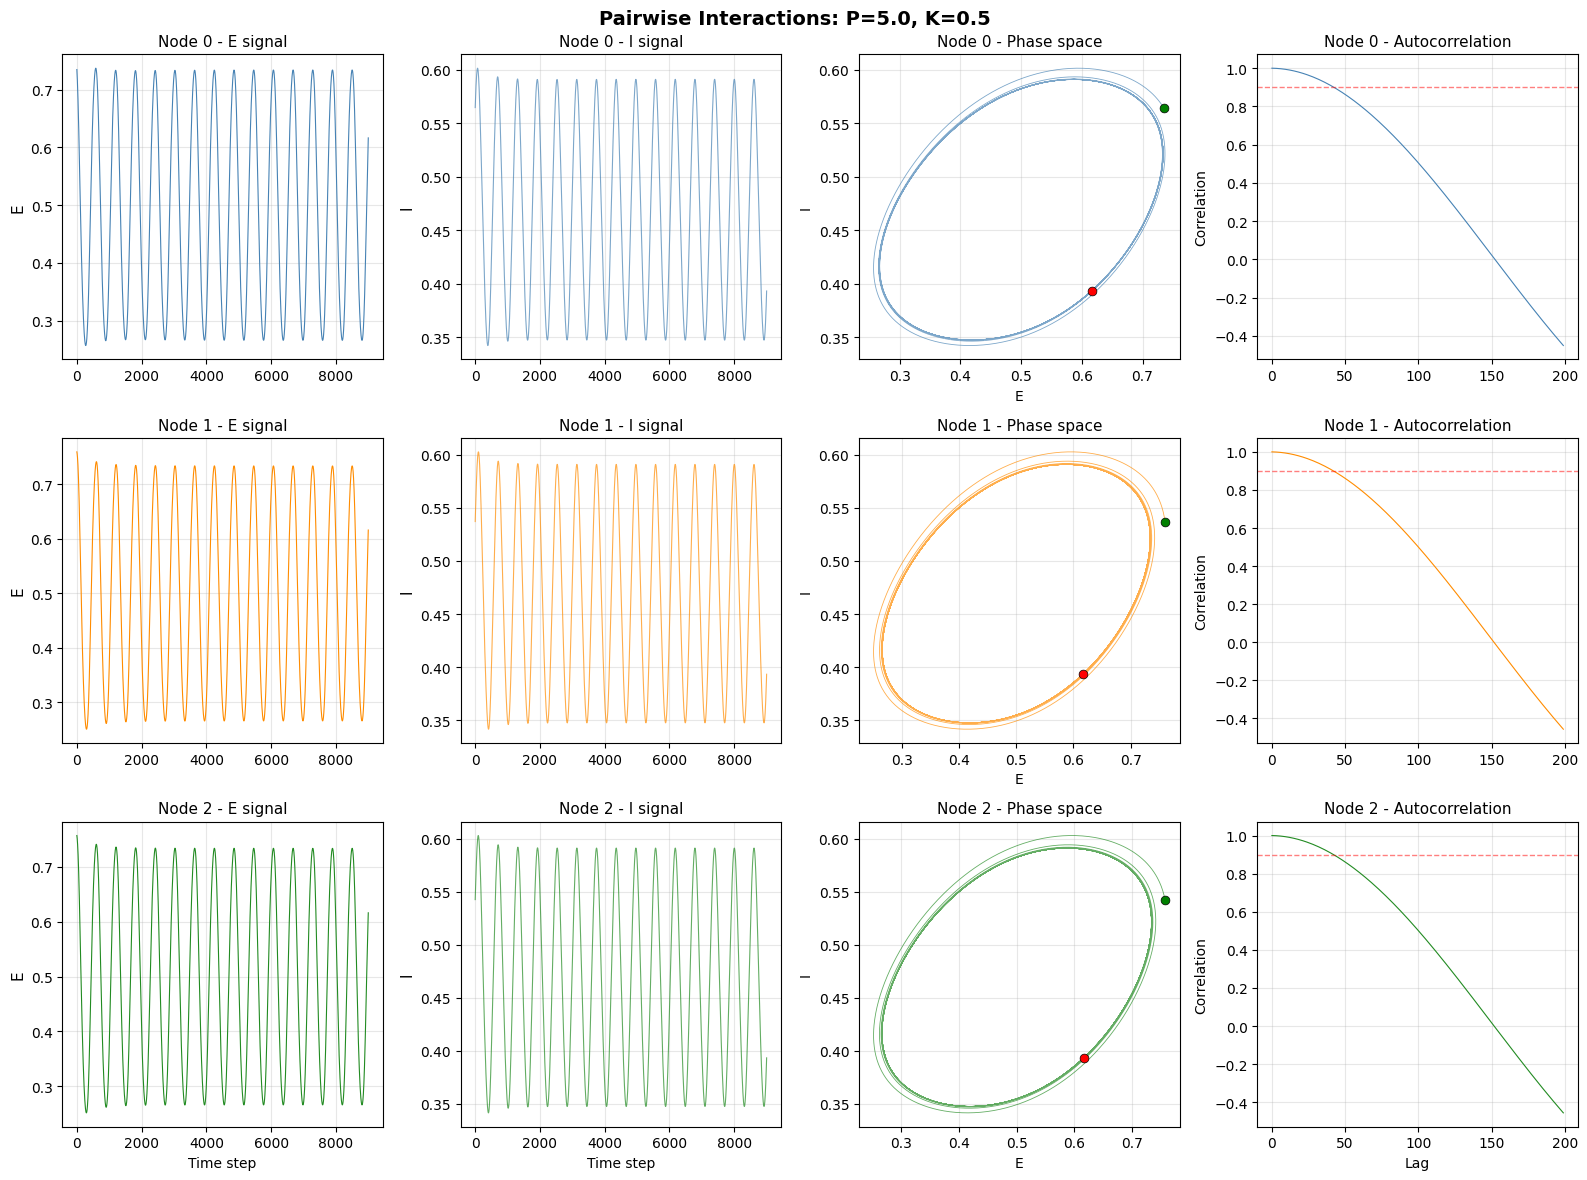

In [2]:
# Simulation parameters
P_sim = 5.0
K_sim = 0.5

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)

# Simulation using the existing function
t, states = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K_sim=K_sim, title="Pairwise Interactions")


---
## **4. Oscillation Detection in $(P \times K$) Space**
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


In [ ]:
# Matrix to store oscillation detection
oscillation_map = np.zeros((len(P_values), len(K_values)), dtype=int)

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):
        # Simulation using the existing function
        t, states = simulate_wc(state0, P_val, K_val, M, T, dt)

        # Remove transient
        start_idx = len(states) // 2
        E = states[start_idx:, :N_nodes]
        I = states[start_idx:, N_nodes:]

        E_node = E[:, 0]
        I_node = I[:, 0]

        # Oscillation detection using the existing function
        is_lc, _, _, _ = detect_limit_cycle_poincare(E_node, I_node, dt)
        oscillation_map[i, j] = int(is_lc)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
plot_oscillation_map(oscillation_map, P_values, K_values, title="Oscillation Detection (P-K)")


Progress: 5/20
Progress: 10/20
Progress: 15/20


---
## **5. Higher-Order Metrics**
We calculate higher-order metrics to analyze interactions in the system.


In [ ]:
# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K3_values)))
DTC_map_noise = np.zeros((len(P_values), len(K3_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K3_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K3_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        t, states = simulate_wc(state0, P_val, K_val, M, T, dt)

        # Remove transient
        start_idx = int(0.3 * len(t))
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing functions
plot_metrics_map(TC_map_noise, P_values, K3_values, title="Total Correlation (TC) with Noise")
plot_metrics_map(DTC_map_noise, P_values, K3_values, title="Dual Total Correlation (DTC) with Noise")
plot_metrics_map(Cumulant_map_noise, P_values, K3_values, title="Third-Order Cumulant with Noise")
plot_metrics_map(PowerCorr_map_noise, P_values, K3_values, title="Triple Power Correlation with Noise")
plot_metrics_map(Entropy_map_noise, P_values, K3_values, title="Entropy with Noise") 

---
## **6. Model with Stochastic Noise**
We add stochastic noise to the excitatory population (E) using the Euler-Maruyama method.

To include biological noise, we extend the excitatory population dynamics using the **Euler-Maruyama method**:

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E} \left(-E_i(t) + S\left(c_{EE} E_i - c_{IE} I_i + P + K \sum_{j} M_{ij} E_j\right)\right)+ \frac{\sigma_E \sqrt{\Delta t}}{\tau_E} \xi_i
$$

- $(\sigma_E)$: Noise intensity for the excitatory population.
- $(\xi_i \sim \mathcal{N}(0, 1))$: Gaussian white noise.

In [ ]:
# Simulation parameters with noise
sigma_E = 0.01

# Simulation with noise using the existing function
t, states = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=sigma_E, higher_order=False)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_signals(t, E, I, title="Pairwirse Interactions with Noise")
# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K_sim=K_sim, title="Pairwise Interactions")


---
## **7. Oscillation Detection in $(P \times K$) Space** with noise
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


In [ ]:
# Matrix to store oscillation detection with noise
oscillation_map_noise = np.zeros((len(P_values), len(K_values)), dtype=int)

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):
        # Simulation with noise using the existing function
        t, states = simulate_wc_stochastic(state0, P_val, K_val, M, T, dt, sigma_E=sigma_E, higher_order=False)

        # Remove transient
        start_idx = len(states) // 2
        E = states[start_idx:, :N_nodes]
        I = states[start_idx:, N_nodes:]

        E_node = E[:, 0]
        I_node = I[:, 0]

        # Oscillation detection using the existing function
        is_lc, _, _, _ = detect_limit_cycle_poincare(E_node, I_node, dt) #, 0.2,0.1)
        oscillation_map_noise[i, j] = int(is_lc)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
plot_oscillation_map(oscillation_map_noise, P_values, K_values, title="Oscillation Detection (P-K) with Noise")


---
## **8. Higher-Order Metrics with noise**
We calculate higher-order metrics to analyze interactions in the system.


In [ ]:
# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K3_values)))
DTC_map_noise = np.zeros((len(P_values), len(K3_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K3_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K3_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        t, states = simulate_wc_stochastic(state0, P_val, K_val, M, T, dt, sigma_E=sigma_E, higher_order=False)

        # Remove transient
        start_idx = int(0.3 * len(t))
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing functions
plot_metrics_map(TC_map_noise, P_values, K3_values, title="Total Correlation (TC) with Noise")
plot_metrics_map(DTC_map_noise, P_values, K3_values, title="Dual Total Correlation (DTC) with Noise")
plot_metrics_map(Cumulant_map_noise, P_values, K3_values, title="Third-Order Cumulant with Noise")
plot_metrics_map(PowerCorr_map_noise, P_values, K3_values, title="Triple Power Correlation with Noise")
plot_metrics_map(Entropy_map_noise, P_values, K3_values, title="Entropy with Noise") 

In [ ]:
from Scripts.simulation import simulate_wc

# Simulación sin ruido
t, states_no_noise = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Extraer señales
E_no_noise = states_no_noise[:, :N_nodes]

# Calcular métricas
Sigma_no_noise = np.cov(E_no_noise.T)
TC_no_noise = TC_gauss(Sigma_no_noise)

if E_no_noise.shape[1] == 3:
    cumulant_no_noise = cumulants(E_no_noise)
    print(f"Third-Order Cumulant (sin ruido): {cumulant_no_noise}")

print(f"Total Correlation (sin ruido): {TC_no_noise}")


In [ ]:
from Scripts.simulation import simulate_wc_stochastic

# Simulación con ruido
t, states_with_noise = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=sigma_E)

# Extraer señales
E_with_noise = states_with_noise[:, :N_nodes]

# Calcular métricas
Sigma_with_noise = np.cov(E_with_noise.T)
TC_with_noise = TC_gauss(Sigma_with_noise)

if E_with_noise.shape[1] == 3:
    cumulant_with_noise = cumulants(E_with_noise)
    print(f"Third-Order Cumulant (con ruido): {cumulant_with_noise}")

print(f"Total Correlation (con ruido): {TC_with_noise}")



In [ ]:
# Generar señales independientes
E_independent = np.random.randn(len(t), N_nodes)

# Calcular métricas
Sigma_independent = np.cov(E_independent.T)
TC_independent = TC_gauss(Sigma_independent)

if E_independent.shape[1] == 3:
    cumulant_independent = cumulants(E_independent)
    print(f"Third-Order Cumulant (independent): {cumulant_independent}")

print(f"Total Correlation (independent): {TC_independent}")


In [ ]:
# Parámetros de simulación
P_sim = 1.0  # Cambiar el valor de P
K_sim = 0.0  # Fuerza de acoplamiento pairwise
state0 = np.random.randn(2 * N_nodes)  # Condiciones iniciales

# Simulación sin ruido
t, states_no_noise = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Simulación con ruido
t, states_with_noise = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=0.01)

# Extraer señales
E_no_noise = states_no_noise[:, :N_nodes]
E_with_noise = states_with_noise[:, :N_nodes]

# Calcular métricas
Sigma_no_noise = np.cov(E_no_noise.T)
Sigma_with_noise = np.cov(E_with_noise.T)

TC_no_noise = TC_gauss(Sigma_no_noise)
TC_with_noise = TC_gauss(Sigma_with_noise)

if E_no_noise.shape[1] == 3:
    cumulant_no_noise = cumulants(E_no_noise)
    cumulant_with_noise = cumulants(E_with_noise)
    print(f"Third-Order Cumulant (sin ruido): {cumulant_no_noise}")
    print(f"Third-Order Cumulant (con ruido): {cumulant_with_noise}")

print(f"Total Correlation (sin ruido): {TC_no_noise}")
print(f"Total Correlation (con ruido): {TC_with_noise}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(t, E_no_noise)
plt.title("Señales sin Ruido")
plt.xlabel("Tiempo")
plt.ylabel("Actividad")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(t, E_with_noise)
plt.title("Señales con Ruido")
plt.xlabel("Tiempo")
plt.ylabel("Actividad")
plt.show()


In [ ]:
TC_map_noise

In [ ]:
P_values, K3_values,

 P_values, K3_values,

In [ ]:
def TC_gauss(Sigma):
    n = Sigma.shape[0]
    H_marginals = 0.0
    for i in range(n):
        H_marginals += entropy_gauss(np.array([[Sigma[i, i]]]))
    H_Sigma = entropy_gauss(Sigma)
    return H_marginals - H_Sigma

def entropy_gauss(Sigma):
    n = Sigma.shape[0]
    Sigma += 1e-9 * np.eye(n)  # Añadir un pequeño término para evitar singularidades
    det = np.linalg.det(Sigma)
    if det <= 0:
        det = 1e-9
    return (n / 2) * np.log(2 * np.pi * np.e) + 0.5 * np.log(det)

In [ ]:
from Scripts.simulation import simulate_wc
state0 = np.random.randn(2 * N_nodes)
# Simulación sin ruido
t, states_no_noise = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Extraer señales
E_no_noise = states_no_noise[:, :N_nodes]

# Calcular métricas
Sigma_no_noise = np.cov(E_no_noise.T)
TC_no_noise = TC_gauss(Sigma_no_noise)

if E_no_noise.shape[1] == 3:
    cumulant_no_noise = cumulants(E_no_noise)
    print(f"Third-Order Cumulant (sin ruido): {cumulant_no_noise}")

print(f"Total Correlation (sin ruido): {TC_no_noise}")


In [ ]:
from Scripts.simulation import simulate_wc_stochastic
state0 = np.random.randn(2 * N_nodes)

# Simulación con ruido
t, states_with_noise = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=1)

# Extraer señales
E_with_noise = states_with_noise[:, :N_nodes]

# Calcular métricas
Sigma_with_noise = np.cov(E_with_noise.T)
TC_with_noise = TC_gauss(Sigma_with_noise)

if E_with_noise.shape[1] == 3:
    cumulant_with_noise = cumulants(E_with_noise)
    print(f"Third-Order Cumulant (con ruido): {cumulant_with_noise}")

print(f"Total Correlation (con ruido): {TC_with_noise}")


In [ ]:
# Generar señales independientes
E_independent = np.random.randn(len(t), N_nodes)

# Calcular métricas
Sigma_independent = np.cov(E_independent.T)
TC_independent = TC_gauss(Sigma_independent)

if E_independent.shape[1] == 3:
    cumulant_independent = cumulants(E_independent)
    print(f"Third-Order Cumulant (independent): {cumulant_independent}")

print(f"Total Correlation (independent): {TC_independent}")

In [ ]:
from Scripts.simulation import simulate_wc_stochastic
from Scripts.parameters import N_nodes, M, T, dt, sigma_E, P_values, K_values

# Parámetros de simulación
P_sim = 5.0
K_sim = 0.0  # Fuerza de acoplamiento pairwise
state0 = np.random.randn(2 * N_nodes)  # Condiciones iniciales

# Simulación con ruido
t, states = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=sigma_E, higher_order=False)

# Extraer señales
E = states[:, :N_nodes]
I = states[:, N_nodes:]
